In [1]:
#Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('Premier_League.csv')

# Preprocessing: Clean 'attendance' column (remove commas and convert to float)
df['attendance'] = df['attendance'].str.replace(',', '').astype(float)

# Show initial data structure
print("Dataset loaded successfully. Shape:", df.shape)
df.head()

Dataset loaded successfully. Shape: (380, 39)


,date,clock,stadium,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,60095.0,Arsenal,5,Wolverhampton Wanderers,0,51.0,49.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,42212.0,Aston Villa,2,Brighton and Hove Albion,1,40.3,59.7,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,17120.0,Brentford,1,Manchester City,0,34.4,65.6,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,40130.0,Chelsea,1,Newcastle United,1,64.4,35.6,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,25198.0,Crystal Palace,1,Nottingham Forest,1,66.0,34.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...


In [2]:
# Data Quality - Handling Missing Values
print("Missing values before processing:")
print(df.isnull().sum().sum()) # Total sum of missing values

# Strategy: Fill numerical missing values with the Median
# Reason: Median is chosen to avoid the influence of extreme scorelines (outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after processing:", df.isnull().sum().sum())

Missing values before processing:
5
Missing values after processing: 0


In [3]:
# Outlier Detection using Interquartile Range (IQR)
# Target column: home_shots
Q1 = df['home_shots'].quantile(0.25)
Q3 = df['home_shots'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering outliers
df_cleaned = df[(df['home_shots'] >= lower_bound) & (df['home_shots'] <= upper_bound)].copy()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")
print(f"Outliers removed: {len(df) - len(df_cleaned)}")

Original dataset size: 380
Cleaned dataset size: 374
Outliers removed: 6


In [5]:
# Normalization and Standardization
# Selecting key performance indicators (KPIs)
features = ['home_possessions', 'away_possessions', 'home_shots', 'away_shots', 'attendance']
data_to_scale = df_cleaned[features]

# 1. Min-Max Scaling: Scaling features to a range [0, 1]
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(min_max_scaler.fit_transform(data_to_scale), columns=features)

# 2. Z-score Standardization: Scaling features to Mean=0 and Std=1
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(data_to_scale), columns=features)

print("Standardized Data (First 5 rows):")
print(df_std.head())

Standardized Data (First 5 rows):
   home_possessions  away_possessions  home_shots  away_shots  attendance
0          0.062336         -0.062336    0.054590   -1.095832    1.254480
1         -0.776176          0.776176   -0.327029   -0.687420    0.140683
2         -1.238533          1.238533   -0.517839    1.150433   -1.422107
3          1.112436         -1.112436    1.581066    0.333609    0.011011
4          1.237821         -1.237821    0.245399   -0.891626   -0.918990


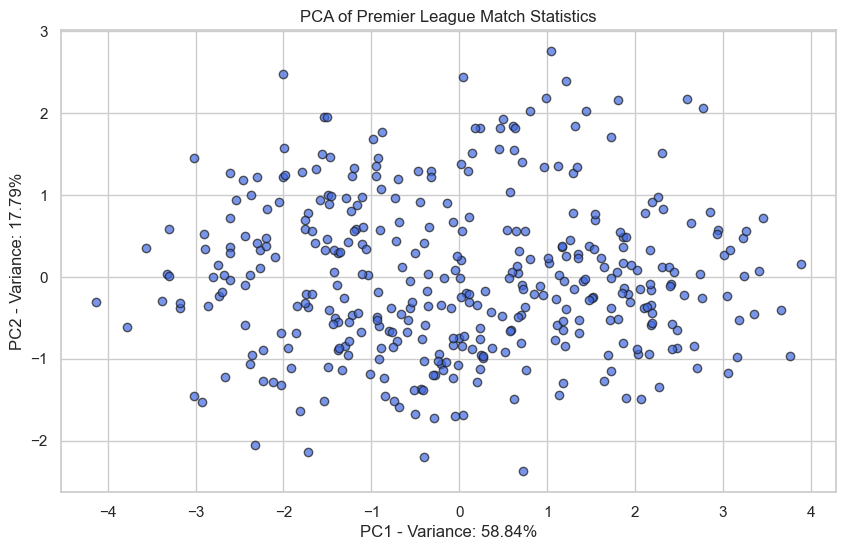

Total variance explained by 2 components: 76.63%


In [6]:
# Cell 5: Dimensionality Reduction using PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_std)

# Create a DataFrame for PCA visualization
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7, c='royalblue', edgecolors='k')
plt.title('PCA of Premier League Match Statistics')
plt.xlabel(f'PC1 - Variance: {pca.explained_variance_ratio_[0]:.2%}')
plt.ylabel(f'PC2 - Variance: {pca.explained_variance_ratio_[1]:.2%}')
plt.show()

# Interpretation of variance
print(f"Total variance explained by 2 components: {np.sum(pca.explained_variance_ratio_):.2%}")

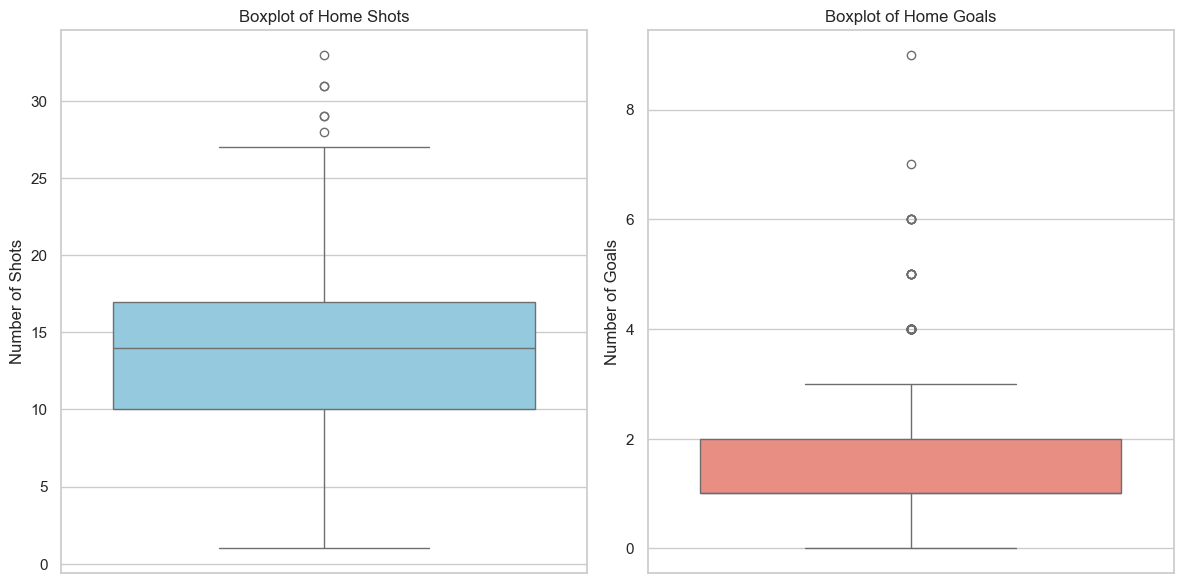

In [7]:
# Boxplot Visualization for Outlier Detection
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 6))

# Subplot 1: Home Shots
plt.subplot(1, 2, 1)
sns.boxplot(y=df['home_shots'], color='skyblue')
plt.title('Boxplot of Home Shots')
plt.ylabel('Number of Shots')

# Subplot 2: Goals Home
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Goals Home'], color='salmon')
plt.title('Boxplot of Home Goals')
plt.ylabel('Number of Goals')

plt.tight_layout()
plt.show()